# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme()

# encode
from sklearn.preprocessing import LabelEncoder

# machine learning
from sklearn.ensemble import RandomForestClassifier

# datetime
from datetime import datetime

# Setting to make numbers easier to read on display
pd.options.display.float_format = '{:20.2f}'.format

# Show all columns on output
pd.set_option('display.max_columns', 999)

In [ ]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Viewing data

In [ ]:
# load dataset
file_path = '/content/drive/MyDrive/0003. FTU SUBJECTS/010. PHÂN TÍCH DỮ LIỆU/04. CUSTOMER SEGMENTATION PROJECT/01. MATERIAL/02. DATASET GỐC/Raw_data.xlsx - CustomerDemographic.csv'
df = pd.read_csv(file_path)

In [ ]:
display(df.head())

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,default,owns_car,tenure
0,1,Laraine,Medendorp,F,93,1953-10-12,Executive Secretary,Health,Mass Customer,N,"""'",Yes,11.00
1,2,Eli,Bockman,Male,81,1980-12-16,Administrative Officer,Financial Services,Mass Customer,N,<script>alert('hi')</script>,Yes,16.00
2,3,Arlin,Dearle,Male,61,1954-01-20,Recruiting Manager,Property,Mass Customer,N,1-thg 2,Yes,15.00
3,4,Talbot,NaN,Male,33,1961-10-03,NaN,IT,Mass Customer,N,() { _; } >_[$($())] { touch /tmp/blns.shellsh...,No,7.00
4,5,Sheila-kathryn,Calton,Female,56,1977-05-13,Senior Editor,NaN,Affluent Customer,N,NIL,Yes,8.00


#Inspect Dataset

----

## Infomation

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          4000 non-null   int64  
 1   first_name                           4000 non-null   object 
 2   last_name                            3875 non-null   object 
 3   gender                               4000 non-null   object 
 4   past_3_years_bike_related_purchases  4000 non-null   int64  
 5   DOB                                  3913 non-null   object 
 6   job_title                            3494 non-null   object 
 7   job_industry_category                3344 non-null   object 
 8   wealth_segment                       4000 non-null   object 
 9   deceased_indicator                   4000 non-null   object 
 10  default                              3698 non-null   object 
 11  owns_car                      

None

----

 **Mô tả ngắn gọn thông tin dữ liệu**

Dữ liệu chứa thông tin về khách hàng của một công ty xe máy, với **4000 bản ghi** và **13 cột**. Dưới đây là mô tả chi tiết từng cột:

| **Tên cột**                              | **Mô tả**                                                                 | **Số giá trị không null** | **Kiểu dữ liệu** |
|------------------------------------------|---------------------------------------------------------------------------|---------------------------|------------------|
| `customer_id`                            | ID duy nhất của khách hàng                                                | 4000                      | `int64`          |
| `first_name`                             | Tên của khách hàng                                                        | 4000                      | `object`         |
| `last_name`                              | Họ của khách hàng                                                         | 3875                      | `object`         |
| `gender`                                 | Giới tính của khách hàng                                                  | 4000                      | `object`         |
| `past_3_years_bike_related_purchases`    | Những sản phẩm mua liên quan đến xe đạp trong 3 năm qua (Pedal, bánh xe, tăm xe, ...)                              | 4000                      | `int64`          |
| `DOB`                                    | Ngày sinh của khách hàng                                                  | 3913                      | `object`         |
| `job_title`                              | Chức danh công việc                                                       | 3494                      | `object`         |
| `job_industry_category`                  | Ngành nghề công việc                                                      | 3344                      | `object`         |
| `wealth_segment`                         | Phân khúc tài sản của khách hàng                                          | 4000                      | `object`         |
| `deceased_indicator`                     | Chỉ số cho biết khách hàng đã qua đời hay chưa                            | 4000                      | `object`         |
| `default`                                | Trường mặc định                                                           | 3698                      | `object`         |
| `owns_car`                               | Khách hàng có sở hữu xe hơi hay không                                     | 4000                      | `object`         |
| `tenure`                                 | Số năm đi làm                                            | 3913                      | `float64`        |

---

**Tổng quan về kiểu dữ liệu**
- **10 cột kiểu `object`**
- **2 cột kiểu `int64`**
- **1 cột kiểu `float64`**

---

## Describe

In [ ]:
# Numerical
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
customer_id,4000.00,2000.50,1154.84,1.00,1000.75,2000.50,3000.25,4000.00
past_3_years_bike_related_purchases,4000.00,48.89,28.72,0.00,24.00,48.00,73.00,99.00
tenure,3913.00,10.66,5.66,1.00,6.00,11.00,15.00,22.00


---

### Mô tả dữ liệu số
- **Sự chênh lệch trong hành vi mua sắm**:
  - Một số khách hàng mua rất ít (0 sản phẩm), trong khi một số khác mua rất nhiều (lên tới 99 sản phẩm). Điều này phản ánh sự khác biệt lớn trong hành vi mua sắm của khách hàng.
- **Thời gian gắn bó (tenure)**:
  - Thời gian gắn bó của khách hàng khá đa dạng, với phần lớn khách hàng có thời gian gắn bó từ **6 đến 15 năm**.
  - Tuy nhiên, có một số khách hàng chỉ gắn bó **1 năm**, điều này cần được phân tích thêm để hiểu nguyên nhân.

---

## Phát hiện bất thường và đề xuất xử lý

### 1. `past_3_years_bike_related_purchases`
- **Bất thường**:
  - Một số khách hàng có giá trị bằng **0**, tức là không mua sản phẩm nào trong 3 năm qua.
- **Đề xuất**:
  - Kiểm tra xem khách hàng có phải là **khách hàng mới** hay không bằng cách so sánh với cột `tenure`.
  - Nếu không phải khách hàng mới, phân loại họ vào nhóm **"tiềm năng"** hoặc **"nguy cơ mất khách hàng"** để triển khai chiến dịch marketing phù hợp.

### 2. `tenure`
- **Bất thường**:
  - Thiếu **87 giá trị** (khoảng **2.175%** tổng số bản ghi).
- **Đề xuất**:
  - Điền giá trị **trung vị (median = 11)** cho các ô bị thiếu vì dữ liệu có độ lệch chuẩn thấp và phân bố tương đối đồng đều.
  - Nếu có thông tin bổ sung (ví dụ: ngày tạo tài khoản), tính toán lại `tenure` dựa trên dữ liệu mới.

---


In [ ]:
# Object
display(df.describe(include='object').T)

,count,unique,top,freq
first_name,4000,3139,Max,5
last_name,3875,3725,Pristnor,3
gender,4000,6,Female,2037
DOB,3913,3448,1978-01-30,7
job_title,3494,195,Business Systems Development Analyst,45
job_industry_category,3344,9,Manufacturing,799
wealth_segment,4000,3,Mass Customer,2000
deceased_indicator,4000,2,N,3998
default,3698,101,"1,00E+02",111
owns_car,4000,2,Yes,2024


### Mô tả dữ liệu chữ

**Phát hiện bất thường và đề xuất xử lý**

## 1 `gender`
- **Bất thường**:
  - Có **6 giá trị khác nhau**, có thể do nhập liệu không đồng nhất (ví dụ: "F", "Female", "Male", v.v.).
- **Đề xuất**:
  - Chuẩn hóa giá trị về hai nhóm chính: **"Male"** và **"Female"**.

---

## 2. `DOB` (Ngày sinh)
- **Bất thường**:
  - Có **87 giá trị bị thiếu**.
- **Đề xuất**:
  - Điền giá trị **trung vị** hoặc **giá trị phổ biến nhất (mode)** vào các ô bị thiếu.

---

## 3. `job_title` và `job_industry_category`
- **Bất thường**:
  - Có nhiều giá trị bị thiếu:
    - `job_title`: Thiếu **506 bản ghi**.
    - `job_industry_category`: Thiếu **656 bản ghi**.
- **Đề xuất**:
  - Sử dụng phương pháp điền giá trị **phổ biến nhất** hoặc phân tích thêm để điền giá trị phù hợp dựa trên các thuộc tính khác của khách hàng.

---

## 4. `default`
- **Bất thường**:
  - Chứa nhiều giá trị bất thường (ví dụ: mã độc, ký tự đặc biệt).
- **Đề xuất**:
  - Làm sạch dữ liệu bằng cách loại bỏ các giá trị không hợp lệ.
  - Chuẩn hóa dữ liệu còn lại để đảm bảo tính nhất quán.

---

## 5. `deceased_indicator`
- **Nhận xét**:
  - Không có gì bất thường, vì hầu hết khách hàng còn sống.

---

## 6. `owns_car`
- **Nhận xét**:
  - Không có gì bất thường, dữ liệu đã rõ ràng.

---

### Kết luận
Dữ liệu có một số bất thường cần được xử lý, đặc biệt ở các cột như `first_name`, `last_name`, `gender`, `DOB`, `job_title`, `job_industry_category`, và `default`. Việc chuẩn hóa và làm sạch dữ liệu sẽ giúp cải thiện chất lượng và độ tin cậy của phân tích.

---

#Data Cleaning
---

## Loại bỏ cột không liên quan

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean.drop(columns=['default'], inplace=True)

In [ ]:
# Check
print(not 'default' in list(df_clean.columns))

True


---

## Handle missing value with small rate

In [ ]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0
job_industry_category,656
job_title,506
last_name,125
DOB,87
tenure,87


In [ ]:
# percentage
missing_percent = (missing / df_clean.shape[0]) * 100
missing_percent

,0
job_industry_category,16.40
job_title,12.65
last_name,3.12
DOB,2.17
tenure,2.17


In [ ]:
# fillna
mode_fill = ['last_name', 'DOB']
df_clean[mode_fill] = df_clean[mode_fill].fillna(df_clean[mode_fill].mode().iloc[0])

median_fill = ['tenure']
df_clean[median_fill] = df_clean[median_fill].fillna(df_clean[median_fill].median())

In [ ]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0
job_industry_category,656
job_title,506


----

**job_industry_category**

In [ ]:
job_industry_category_counts = df_clean['job_industry_category'].value_counts().reset_index()
job_industry_category_counts.columns = ['job_industry_category', 'count']
job_industry_category_counts

,job_industry_category,count
0,Manufacturing,799
1,Financial Services,774
2,Health,602
3,Retail,358
4,Property,267
5,IT,223
6,Entertainment,136
7,Argiculture,113
8,Telecommunications,72


---

**job_title**

In [ ]:
job_title_counts = df_clean['job_title'].value_counts().reset_index()
job_title_counts.columns = ['job_title', 'count']
job_title_counts

,job_title,count
0,Business Systems Development Analyst,45
1,Tax Accountant,44
2,Social Worker,44
3,Internal Auditor,42
4,Recruiting Manager,41
...,...,...
190,Database Administrator I,4
191,Health Coach I,3
192,Health Coach III,3
193,Research Assistant III,3


## Chuẩn hoá với cột gender

In [ ]:
df_clean['gender'].value_counts()

,count
gender,
Female,2037
Male,1872
U,88
F,1
Femal,1
M,1


<Axes: xlabel='gender', ylabel='count'>

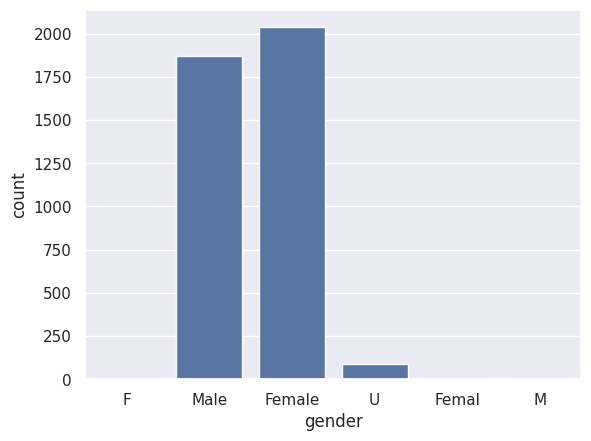

In [ ]:
sns.countplot(data=df_clean, x='gender')

In [ ]:
gender_mapping = {
    'M': 'Male',
    'F': 'Female',
    'Femal': 'Female',
    'Male': 'Male',
    'Female': 'Female',
    'U': 'Unknown'
}

df_clean['gender'] = df_clean['gender'].map(gender_mapping)

In [ ]:
df_clean['gender'].value_counts()

,count
gender,
Female,2039
Male,1873
Unknown,88


## Date of Birth

In [ ]:
# Chuyển đổi DOB thành tuổi
current_year = datetime.now().year
df_clean['Age'] = df_clean['DOB'].apply(lambda x: current_year - int(x.split('-')[0]) if pd.notnull(x) else np.nan)

<Axes: xlabel='Age', ylabel='Count'>

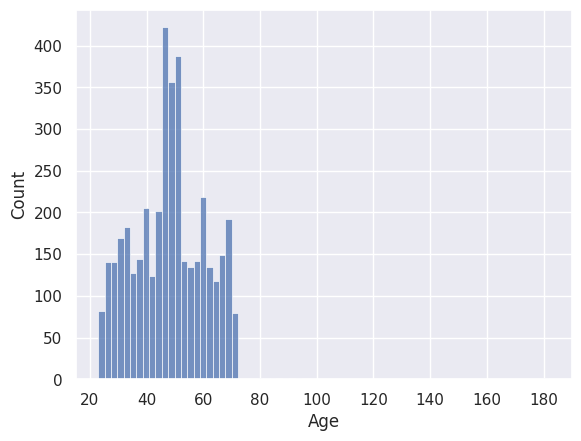

In [ ]:
sns.histplot(data=df_clean, x='Age')

In [ ]:
df_clean['Age'].describe()

,Age
count,4000.00
mean,47.95
std,12.66
min,23.00
25%,39.00
50%,48.00
75%,57.00
max,182.00


In [ ]:
# show age > 100
display(df_clean[df_clean['Age'] > 100])

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,Age
33,34,Jephthah,Bachmann,Unknown,59,1843-12-21,Legal Assistant,IT,Affluent Customer,N,No,20.00,182


In [ ]:
# filter age <= 100
df_clean = df_clean[df_clean['Age'] <= 100]

<Axes: xlabel='Age', ylabel='Count'>

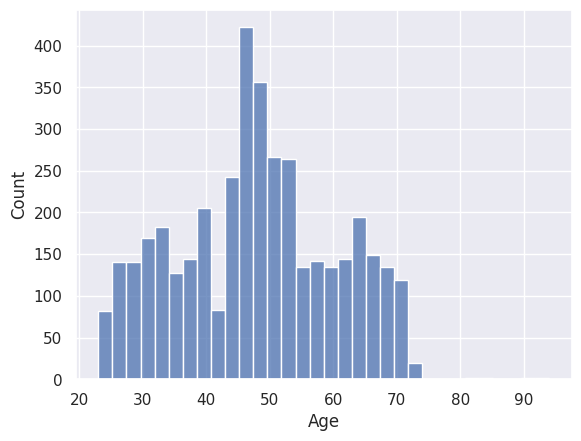

In [ ]:
sns.histplot(data=df_clean, x='Age')

In [ ]:
df_clean['Age'].describe()

,Age
count,3999.00
mean,47.91
std,12.48
min,23.00
25%,39.00
50%,48.00
75%,57.00
max,94.00


In [ ]:
# filter age > 80
df_clean[df_clean['Age'] > 80]

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,Age
657,658,Donn,Bonnell,Male,38,1944-01-24,Tax Accountant,Manufacturing,Affluent Customer,N,Yes,8.00,81
719,720,Darrel,Canet,Male,67,1931-10-23,Recruiting Manager,Retail,Affluent Customer,N,No,6.00,94
1091,1092,Katlin,Creddon,Female,56,1935-08-22,VP Quality Control,Retail,Mass Customer,N,No,5.00,90
2412,2413,Abbey,Murrow,Male,27,1943-08-11,Environmental Specialist,Manufacturing,High Net Worth,N,Yes,17.00,82
3409,3410,Merrili,Brittin,Female,93,1940-09-22,NaN,Property,Mass Customer,N,No,16.00,85


## Handle missing value with high rate

In [ ]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0
job_industry_category,656
job_title,506


- **Dữ liệu không thiếu giá trị (train_data)**: Dùng để huấn luyện mô hình Random Forest.
- Chọn ra những đặc trưng tốt nhất và suy đoán dựa trên đặc trưng đó

In [ ]:
# Xác định features and target
target_columns = ['job_industry_category']

nominal_features = ['gender', 'deceased_indicator', 'owns_car']

ordianal_features = ['wealth_segment']

numerical_features = ['past_3_years_bike_related_purchases', 'tenure', 'Age']

features = nominal_features + numerical_features + ordianal_features

In [ ]:
# Tạo dữ liệu train
def prepare_data_for_imputation(df, target_column, features):
    train_data = df[df[target_column].notna()]
    X_train = train_data[features]
    y_train = train_data[target_column]
    return X_train, y_train

### job_industry_category

In [ ]:
X_train_job_ind, y_train_job_ind = prepare_data_for_imputation(df_clean, 'job_industry_category', features = features)
print(f'X_train_job_ind: {X_train_job_ind.shape}')
print(f'y_train_job_ind: {y_train_job_ind.shape}')

X_train_job_ind: (3343, 7)
y_train_job_ind: (3343,)


In [ ]:
# mapping for ordinal features
X_train_job_ind['wealth_segment'] = (
    X_train_job_ind['wealth_segment']
    .map({'High Net Worth': 2,
          'Affluent Customer': 1,
          'Mass Customer': 0})
)

In [ ]:
# get dummies
X_train_job_ind = pd.get_dummies(X_train_job_ind, columns=nominal_features, drop_first=True)

In [ ]:
# In ra kích thước của dữ liệu đã được chuyển đổi
print(f'X_train_job_ind_transformed: {X_train_job_ind.shape}')
print(f'y_train_job_ind: {y_train_job_ind.shape}')

X_train_job_ind_transformed: (3343, 8)
y_train_job_ind: (3343,)


In [ ]:
# Train a Random Forest Model
rf_job_ind = RandomForestClassifier(n_estimators=100, random_state=42)
rf_job_ind.fit(X_train_job_ind, y_train_job_ind)

RandomForestClassifier(random_state=42)

In [ ]:
# Get feature importance
importance = rf_job_ind.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_train_job_ind.columns,
    'Importance': importance
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance from Random Forest")
importance_df

Feature Importance from Random Forest


,Feature,Importance
0,past_3_years_bike_related_purchases,0.36
2,Age,0.30
1,tenure,0.23
3,wealth_segment,0.05
7,owns_car_Yes,0.03
4,gender_Male,0.02
5,gender_Unknown,0.02
6,deceased_indicator_Y,0.00


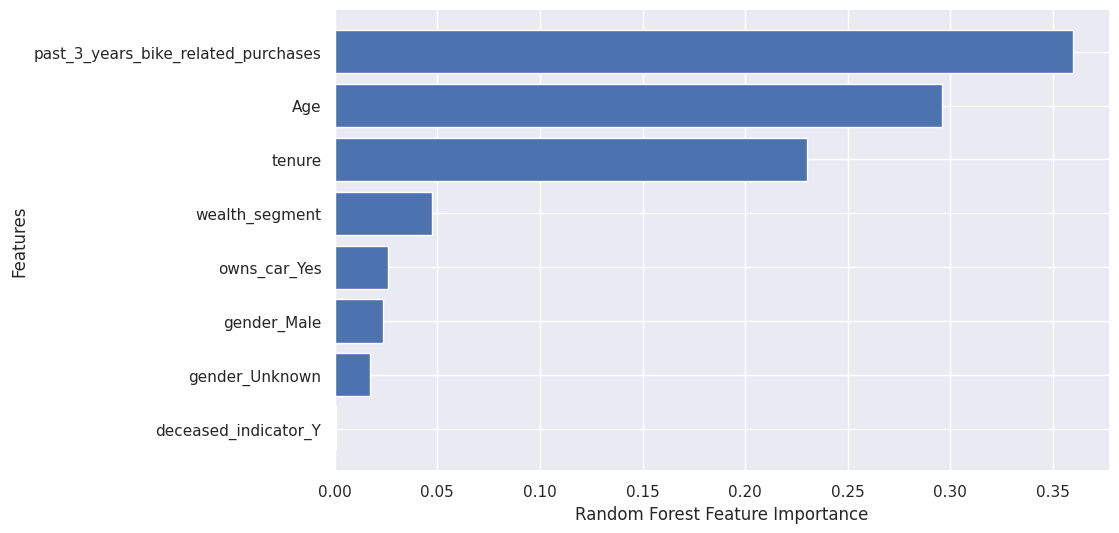

In [ ]:
# Plot features importance
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
# Nhóm theo nhiều cột
grouped_mode = df_clean.groupby(['wealth_segment', 'past_3_years_bike_related_purchases'])['job_industry_category'].apply(lambda x: x.mode()[0])
grouped_mode

wealth_segment     past_3_years_bike_related_purchases
Affluent Customer  0                                           Manufacturing
                   1                                           Manufacturing
                   2                                           Manufacturing
                   3                                           Entertainment
                   4                                      Financial Services
                                                                 ...        
Mass Customer      95                                            Argiculture
                   96                                          Manufacturing
                   97                                                 Health
                   98                                          Manufacturing
                   99                                     Financial Services
Name: job_industry_category, Length: 300, dtype: object

In [ ]:
# Điền giá trị bị thiếu
def fill_missing_job_industry(row):
    key = (row['wealth_segment'], row['past_3_years_bike_related_purchases'])
    if pd.isnull(row['job_industry_category']):
        return grouped_mode[key]
    else:
        return row['job_industry_category']

df_clean['job_industry_category'] = df_clean.apply(fill_missing_job_industry, axis=1)

In [ ]:
origin_df = df['job_industry_category'].value_counts()
new_df = df_clean['job_industry_category'].value_counts()

# Nối 2 bảng
df_compare = pd.concat([origin_df, new_df], axis=1)
df_compare.columns = ['Origin', 'New']
df_compare

,Origin,New
job_industry_category,,
Manufacturing,799,998
Financial Services,774,1020
Health,602,738
Retail,358,374
Property,267,280
IT,223,251
Entertainment,136,141
Argiculture,113,123
Telecommunications,72,74


In [ ]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0
job_title,506


---

### job_title

In [ ]:
# Xác định features and target
target_columns = ['job_title']

nominal_features = ['gender', 'deceased_indicator', 'owns_car', 'job_industry_category']

ordianal_features = ['wealth_segment']

numerical_features = ['past_3_years_bike_related_purchases', 'tenure', 'Age']

features = nominal_features + numerical_features + ordianal_features

In [ ]:
X_train_job_title, y_train_job_title = prepare_data_for_imputation(df_clean, 'job_title', features = features)
print(f'X_train_job_title: {X_train_job_title.shape}')
print(f'y_train_job_title: {y_train_job_title.shape}')

X_train_job_title: (3493, 8)
y_train_job_title: (3493,)


In [ ]:
# mapping
X_train_job_title['wealth_segment'] = (
    X_train_job_title['wealth_segment']
    .map({'High Net Worth': 2,
          'Affluent Customer': 1,
          'Mass Customer': 0}))

In [ ]:
# get dummies
X_train_job_title = pd.get_dummies(X_train_job_title, columns=nominal_features, drop_first=True)

In [ ]:
# in ra kích thước đã chuyển đổi
print(f'X_train_job_title_transformed: {X_train_job_title.shape}')
print(f'y_train_job_title: {y_train_job_title.shape}')

X_train_job_title_transformed: (3493, 16)
y_train_job_title: (3493,)


In [ ]:
# Train a Random Forest Model
rf_job_title = RandomForestClassifier(n_estimators=100, random_state=42)
rf_job_title.fit(X_train_job_title, y_train_job_title)

RandomForestClassifier(random_state=42)

In [ ]:
# Get feature importance
importance = rf_job_title.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_train_job_title.columns,
    'Importance': importance
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance from Random Forest")
importance_df

Feature Importance from Random Forest


,Feature,Importance
0,past_3_years_bike_related_purchases,0.31
2,Age,0.27
1,tenure,0.24
3,wealth_segment,0.07
7,owns_car_Yes,0.04
4,gender_Male,0.04
8,job_industry_category_Entertainment,0.01
10,job_industry_category_Health,0.00
13,job_industry_category_Property,0.00
11,job_industry_category_IT,0.00


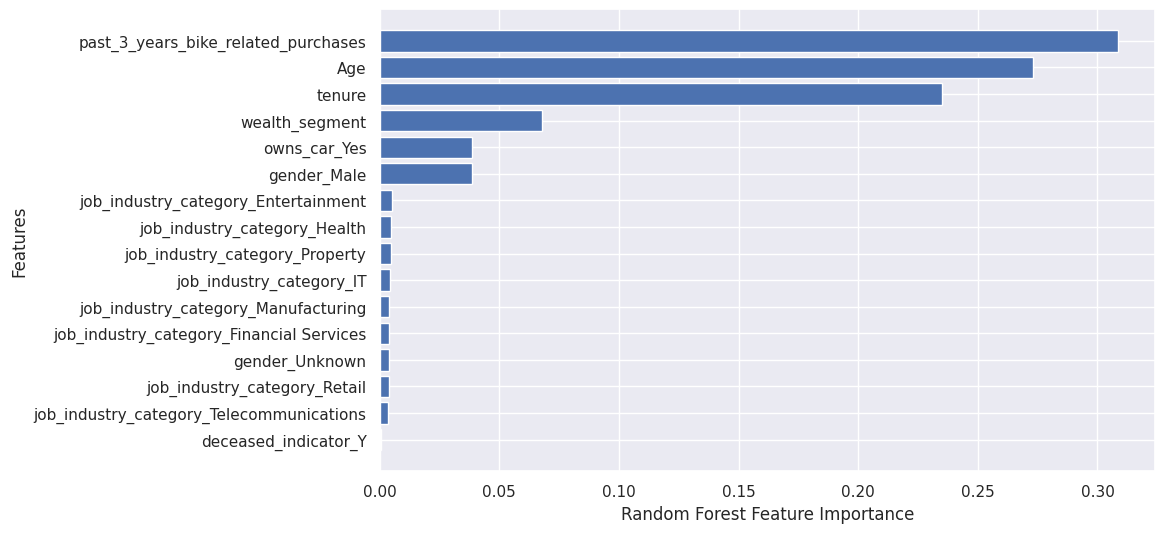

In [ ]:
# Plot features importance
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
# Nhóm theo nhiều cột
grouped_mode = df_clean.groupby(['wealth_segment','past_3_years_bike_related_purchases'])['job_title'].apply(lambda x: x.mode()[0])
grouped_mode

wealth_segment     past_3_years_bike_related_purchases
Affluent Customer  0                                                        Analyst Programmer
                   1                                                             Accountant IV
                   2                                                                   Actuary
                   3                                                   Human Resources Manager
                   4                                                           General Manager
                                                                          ...                 
Mass Customer      95                                               Desktop Support Technician
                   96                                     Business Systems Development Analyst
                   97                                                         Internal Auditor
                   98                                              Information Systems Manager
                   99                                                         Junior Executive
Name: job_title, Length: 300, dtype: object

In [ ]:
# Điền giá trị bị thiếu
def fill_missing_job_title(row):
    key = (row['wealth_segment'], row['past_3_years_bike_related_purchases'])
    if pd.isnull(row['job_title']):
        return grouped_mode[key]
    else:
        return row['job_title']

df_clean['job_title'] = df_clean.apply(fill_missing_job_title, axis=1)

In [ ]:
origin_df = df['job_title'].value_counts()
new_df = df_clean['job_title'].value_counts()

# nối 2 bảng
df_compare = pd.concat([origin_df, new_df], axis=1)
df_compare.columns = ['Origin', 'New']
df_compare = df_compare[df_compare['Origin'] != df_compare['New']]
df_compare

,Origin,New
job_title,,
Business Systems Development Analyst,45,61
Tax Accountant,44,46
Social Worker,44,46
Internal Auditor,42,46
Legal Assistant,41,43
...,...,...
Account Representative III,6,18
Administrative Assistant I,6,18
Automation Specialist III,5,7


In [ ]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0


## Kiểm tra dữ liệu trùng lặp

In [ ]:
df_clean.duplicated().sum()

0

# So sánh data clean và data gốc

In [ ]:
percentage = len(df_clean) / len(df) * 100
print(f'Data clean chiếm  {percentage:.2f}% so với data gốc')

Data clean chiếm  99.98% so với data gốc


# Sắp xếp lại các cột

In [ ]:
print(f'Số cột của data gốc: {len(df.columns)}')
print(f'Số cột của data clean: {len(df_clean.columns)}')

Số cột của data gốc: 13
Số cột của data clean: 13


In [ ]:
# Lấy danh sách các cột kiểu object
object_columns = df_clean.select_dtypes(include=['object']).columns.tolist()

# Lấy danh sách các cột kiểu numeric
numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Sắp xếp lại thứ tự cột: Numeric -> Object
df_clean = df_clean[numeric_columns + object_columns]

# Kiểm tra số cột
print(f'Số cột của data clean sau khi sắp xếp cột : {len(df_clean.columns)}')

Số cột của data clean sau khi sắp xếp cột : 13


# Lưu data đã được làm sạch

In [ ]:
df_clean.to_csv('Cleaned_CustomerDemographic.csv', index=False)